# Superstore Sales and Demand Forecasting

## Project objective

The purpose of this project is to analyze historical Superstore transactions and build forecasting models that estimate future monthly sales.

The project includes:

- data loading and validation
- data cleaning
- exploratory data analysis
- monthly sales aggregation
- time-based feature engineering
- chronological train-test splitting
- Linear Regression
- Random Forest
- Exponential Smoothing
- model evaluation using MAE, RMSE, and MAPE
- future sales forecasting
- business recommendations

## Forecasting target & Forecast horizon

The target variable is total monthly sales.

The final model will forecast the next 12 months after the final date in the dataset.

## Important forecasting rules

- Dates be sorted chronologically.
- Training data must occur before test data.
- Random train-test splitting will not be used.
- Lag and rolling features must use only past observations.
- Test-period actual sales must not be used to create training features.

In [1]:
# Standard library imports
from pathlib import Path
import sys
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Display settings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Libraries imported successfully.")
print(f"Python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully.
Python version: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
pandas version: 3.0.5
NumPy version: 2.5.1


In [2]:
# The notebook is saved inside:
# project_root/notebooks/
# Therefore, ".." points to the project root.

PROJECT_ROOT = Path.cwd().parent

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_FILE = DATA_RAW_DIR / "Sample - Superstore.csv"

print(f"Current notebook directory: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_FILE}")

Current notebook directory: c:\Users\Enat\Documents\superstore-sales-forecasting\notebooks
Project root: c:\Users\Enat\Documents\superstore-sales-forecasting
Dataset path: c:\Users\Enat\Documents\superstore-sales-forecasting\data\raw\Sample - Superstore.csv


In [3]:
# Create required folders if they do not already exist.

required_directories = [
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    MODELS_DIR,
]

for directory in required_directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Required project directories are available.")

Required project directories are available.


In [4]:
# Verify that the expected CSV file exists before loading it.

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_FILE}\n\n"
        "Download 'Sample - Superstore.csv' from Kaggle and place it "
        "inside the data/raw folder."
    )

print("Dataset file found.")
print(f"File name: {DATA_FILE.name}")
print(f"File size: {DATA_FILE.stat().st_size / 1_000_000:.2f} MB")

Dataset file found.
File name: Sample - Superstore.csv
File size: 2.29 MB


In [6]:
# Load the raw Superstore transaction dataset.

df_raw = pd.read_csv(
    DATA_FILE,
    encoding="windows-1252"
)

print("Dataset loaded successfully.")
print(f"Number of rows: {df_raw.shape[0]:,}")
print(f"Number of columns: {df_raw.shape[1]}")

Dataset loaded successfully.
Number of rows: 9,994
Number of columns: 21


In [7]:
# Display the first five rows.

df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [8]:
# Display the final five rows.

df_raw.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.25,3,0.20,4.10
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.96,2,0.00,15.63
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.58,2,0.20,19.39
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4,0.00,13.32
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.16,2,0.00,72.95


In [9]:
# Print every column name.

print("Dataset columns:\n")

for position, column_name in enumerate(df_raw.columns, start=1):
    print(f"{position:>2}. {column_name}")

Dataset columns:

 1. Row ID
 2. Order ID
 3. Order Date
 4. Ship Date
 5. Ship Mode
 6. Customer ID
 7. Customer Name
 8. Segment
 9. Country
10. City
11. State
12. Postal Code
13. Region
14. Product ID
15. Category
16. Sub-Category
17. Product Name
18. Sales
19. Quantity
20. Discount
21. Profit


In [10]:
# Define columns that are essential for the forecasting analysis.

required_columns = {
    "Order Date",
    "Ship Date",
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
}

missing_required_columns = required_columns.difference(df_raw.columns)

if missing_required_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        f"{sorted(missing_required_columns)}"
    )

print("All required columns are present.")

All required columns are present.


In [11]:
# Inspect the current data types and non-null counts.

df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [12]:
# Display data types as a table.

data_types = (
    df_raw.dtypes
    .astype(str)
    .rename("data_type")
    .reset_index()
    .rename(columns={"index": "column"})
)

data_types

,column,data_type
0,Row ID,int64
1,Order ID,str
2,Order Date,str
3,Ship Date,str
4,Ship Mode,str
5,Customer ID,str
6,Customer Name,str
7,Segment,str
8,Country,str
9,City,str


In [13]:
# Perform initial structural checks.

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")
print(f"Completely duplicated rows: {df_raw.duplicated().sum():,}")
print(f"Unique order IDs: {df_raw['Order ID'].nunique():,}")
print(f"Unique customers: {df_raw['Customer ID'].nunique():,}")
print(f"Unique products: {df_raw['Product ID'].nunique():,}")

Rows: 9,994
Columns: 21
Completely duplicated rows: 0
Unique order IDs: 5,009
Unique customers: 793
Unique products: 1,862


In [14]:
# Count missing values in every column.

missing_summary = (
    df_raw.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df_raw) * 100
)

missing_summary = (
    missing_summary
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_percentage
Row ID,0,0.00
Order ID,0,0.00
Order Date,0,0.00
Ship Date,0,0.00
Ship Mode,0,0.00
Customer ID,0,0.00
Customer Name,0,0.00
Segment,0,0.00
Country,0,0.00
City,0,0.00


In [15]:
# Show only columns that contain at least one missing value.

columns_with_missing_values = missing_summary[
    missing_summary["missing_count"] > 0
]

if columns_with_missing_values.empty:
    print("No missing values were detected.")
else:
    display(columns_with_missing_values)

No missing values were detected.


In [16]:
# Identify exact duplicate rows.

duplicate_count = df_raw.duplicated().sum()

print(f"Number of exact duplicate rows: {duplicate_count:,}")

Number of exact duplicate rows: 0


In [17]:
# Generate descriptive statistics for numerical columns.

numerical_summary = df_raw[
    ["Sales", "Quantity", "Discount", "Profit"]
].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"


In [18]:
# Inspect key categorical columns.

categorical_columns = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category",
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(df_raw[column].value_counts(dropna=False))


Ship Mode
---------
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

Segment
-------
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Region
------
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Category
--------
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Sub-Category
------------
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


In [19]:
# Inspect date values before converting them.

print("Sample Order Date values:")
display(df_raw["Order Date"].head(10))

print("\nSample Ship Date values:")
display(df_raw["Ship Date"].head(10))

Sample Order Date values:


0     11/8/2016
1     11/8/2016
2     6/12/2016
3    10/11/2015
4    10/11/2015
5      6/9/2014
6      6/9/2014
7      6/9/2014
8      6/9/2014
9      6/9/2014
Name: Order Date, dtype: str


Sample Ship Date values:


0    11/11/2016
1    11/11/2016
2     6/16/2016
3    10/18/2015
4    10/18/2015
5     6/14/2014
6     6/14/2014
7     6/14/2014
8     6/14/2014
9     6/14/2014
Name: Ship Date, dtype: str

In [20]:
# Examine the raw date range as text.
# These are text-based min and max values, so they should not yet
# be interpreted as the true chronological range.

print(f"Raw minimum Order Date text: {df_raw['Order Date'].min()}")
print(f"Raw maximum Order Date text: {df_raw['Order Date'].max()}")

Raw minimum Order Date text: 1/1/2017
Raw maximum Order Date text: 9/9/2017


In [21]:
# Build a compact initial audit table.

audit_summary = pd.DataFrame(
    {
        "metric": [
            "Number of rows",
            "Number of columns",
            "Exact duplicate rows",
            "Missing values",
            "Unique orders",
            "Unique customers",
            "Unique products",
        ],
        "value": [
            len(df_raw),
            df_raw.shape[1],
            df_raw.duplicated().sum(),
            int(df_raw.isna().sum().sum()),
            df_raw["Order ID"].nunique(),
            df_raw["Customer ID"].nunique(),
            df_raw["Product ID"].nunique(),
        ],
    }
)

audit_summary

,metric,value
0,Number of rows,9994
1,Number of columns,21
2,Exact duplicate rows,0
3,Missing values,0
4,Unique orders,5009
5,Unique customers,793
6,Unique products,1862


In [22]:
# Save the initial dataset audit for reproducibility.

audit_output_path = TABLES_DIR / "initial_dataset_audit.csv"

audit_summary.to_csv(
    audit_output_path,
    index=False,
)

print(f"Initial audit saved to:\n{audit_output_path}")

Initial audit saved to:
c:\Users\Enat\Documents\superstore-sales-forecasting\outputs\tables\initial_dataset_audit.csv


In [23]:
# Create a working copy.
#
# We preserve df_raw unchanged so that we can always compare the cleaned
# dataset with the original source data.

df = df_raw.copy(deep=True)

print("Working copy created.")
print(f"Raw dataframe shape: {df_raw.shape}")
print(f"Working dataframe shape: {df.shape}")

Working copy created.
Raw dataframe shape: (9994, 21)
Working dataframe shape: (9994, 21)


# 3. Data cleaning and validation

The cleaning process will:

- standardize column names
- remove exact duplicate rows if any
- convert dates to datetime values
- convert business measures to numeric values
- handle missing values if any
- validate invalid sales, quantity, and discount values
- sort transactions chronologically
- save a cleaned transaction-level dataset

Rows missing the forecasting date or sales target will be removed because these fields cannot be safely imputed for forecasting.

In [25]:
df = df_raw.copy(deep=True)

print(f"Starting shape: {df.shape}")

Starting shape: (9994, 21)


In [26]:
def clean_column_name(column_name: str) -> str:
    """Convert a column name to lowercase snake_case."""
    return (
        column_name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


df.columns = [clean_column_name(column) for column in df.columns]

print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [27]:
original_row_count = len(df)
original_duplicate_count = int(df.duplicated().sum())

print(f"Original rows: {original_row_count:,}")
print(f"Exact duplicate rows: {original_duplicate_count:,}")

Original rows: 9,994
Exact duplicate rows: 0


In [28]:
df = df.drop_duplicates().copy()

print(f"Rows after duplicate removal: {len(df):,}")
print(f"Rows removed: {original_row_count - len(df):,}")

Rows after duplicate removal: 9,994
Rows removed: 0


In [29]:
date_columns = ["order_date", "ship_date"]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

print(df[date_columns].dtypes)

order_date    datetime64[us]
ship_date     datetime64[us]
dtype: object


In [30]:
for column in date_columns:
    failed_count = int(df[column].isna().sum())
    print(f"{column}: {failed_count:,} missing or invalid dates")

order_date: 0 missing or invalid dates
ship_date: 0 missing or invalid dates


In [31]:
numeric_columns = [
    "sales",
    "quantity",
    "discount",
    "profit",
    "postal_code",
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

df[numeric_columns].dtypes

sales          float64
quantity         int64
discount       float64
profit         float64
postal_code      int64
dtype: object

In [32]:
missing_after_conversion = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

missing_after_conversion["missing_percentage"] = (
    missing_after_conversion["missing_count"] / len(df) * 100
)

missing_after_conversion[
    missing_after_conversion["missing_count"] > 0
]

,missing_count,missing_percentage


In [33]:
rows_before_critical_drop = len(df)

df = df.dropna(
    subset=["order_date", "sales"]
).copy()

critical_rows_removed = rows_before_critical_drop - len(df)

print(f"Rows removed for missing order date or sales: {critical_rows_removed:,}")

Rows removed for missing order date or sales: 0


In [34]:
categorical_columns = [
    "ship_mode",
    "customer_id",
    "customer_name",
    "segment",
    "country",
    "city",
    "state",
    "region",
    "product_id",
    "category",
    "sub_category",
    "product_name",
]

for column in categorical_columns:
    if column in df.columns:
        df[column] = df[column].fillna("Unknown")


optional_numeric_columns = [
    "quantity",
    "discount",
    "profit",
]

for column in optional_numeric_columns:
    if column in df.columns and df[column].isna().any():
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value)
        print(f"Filled missing {column} values with median {median_value:.2f}")

In [35]:
if "postal_code" in df.columns:
    df["postal_code"] = df["postal_code"].astype("Int64")

In [36]:
validation_summary = pd.Series(
    {
        "sales_less_than_zero": int((df["sales"] < 0).sum()),
        "sales_equal_zero": int((df["sales"] == 0).sum()),
        "quantity_less_than_or_equal_zero": int(
            (df["quantity"] <= 0).sum()
        ),
        "discount_below_zero": int(
            (df["discount"] < 0).sum()
        ),
        "discount_above_one": int(
            (df["discount"] > 1).sum()
        ),
        "ship_date_before_order_date": int(
            (df["ship_date"] < df["order_date"]).sum()
        ),
    },
    name="count",
)

validation_summary.to_frame()

,count
sales_less_than_zero,0
sales_equal_zero,0
quantity_less_than_or_equal_zero,0
discount_below_zero,0
discount_above_one,0
ship_date_before_order_date,0


In [37]:
rows_before_validation = len(df)

df = df[
    (df["sales"] >= 0)
    & (df["quantity"] > 0)
    & (df["discount"].between(0, 1))
].copy()

invalid_rows_removed = rows_before_validation - len(df)

print(f"Invalid business rows removed: {invalid_rows_removed:,}")

Invalid business rows removed: 0


In [38]:
sort_columns = ["order_date"]

if "row_id" in df.columns:
    sort_columns.append("row_id")

df = (
    df.sort_values(sort_columns)
    .reset_index(drop=True)
)

print(f"First order date: {df['order_date'].min():%Y-%m-%d}")
print(f"Last order date: {df['order_date'].max():%Y-%m-%d}")

First order date: 2014-01-03
Last order date: 2017-12-30


In [39]:
cleaning_report = pd.DataFrame(
    {
        "metric": [
            "Original rows",
            "Exact duplicates removed",
            "Critical missing rows removed",
            "Invalid business rows removed",
            "Final cleaned rows",
            "Final columns",
            "Remaining missing values",
            "First order date",
            "Last order date",
        ],
        "value": [
            original_row_count,
            original_duplicate_count,
            critical_rows_removed,
            invalid_rows_removed,
            len(df),
            df.shape[1],
            int(df.isna().sum().sum()),
            df["order_date"].min().strftime("%Y-%m-%d"),
            df["order_date"].max().strftime("%Y-%m-%d"),
        ],
    }
)

cleaning_report

,metric,value
0,Original rows,9994
1,Exact duplicates removed,0
2,Critical missing rows removed,0
3,Invalid business rows removed,0
4,Final cleaned rows,9994
5,Final columns,21
6,Remaining missing values,0
7,First order date,2014-01-03
8,Last order date,2017-12-30


# 4. Exploratory data analysis

Exploratory data analysis helps us understand:

- the overall scale of sales
- sales and profit distributions
- category and regional performance
- historical trends
- seasonal patterns
- unusual transactions

In [41]:
business_summary = pd.DataFrame(
    {
        "metric": [
            "Total sales",
            "Total profit",
            "Total quantity",
            "Number of transactions",
            "Unique orders",
            "Unique customers",
            "Unique products",
            "Average transaction sales",
            "Median transaction sales",
        ],
        "value": [
            df["sales"].sum(),
            df["profit"].sum(),
            df["quantity"].sum(),
            len(df),
            df["order_id"].nunique(),
            df["customer_id"].nunique(),
            df["product_id"].nunique(),
            df["sales"].mean(),
            df["sales"].median(),
        ],
    }
)

business_summary

,metric,value
0,Total sales,"2,297,200.86"
1,Total profit,"286,397.02"
2,Total quantity,"37,873.00"
3,Number of transactions,"9,994.00"
4,Unique orders,"5,009.00"
5,Unique customers,793.00
6,Unique products,"1,862.00"
7,Average transaction sales,229.86
8,Median transaction sales,54.49


In [42]:
business_summary.to_csv(
    TABLES_DIR / "business_summary.csv",
    index=False
)

In [43]:
df[
    ["sales", "quantity", "discount", "profit"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"


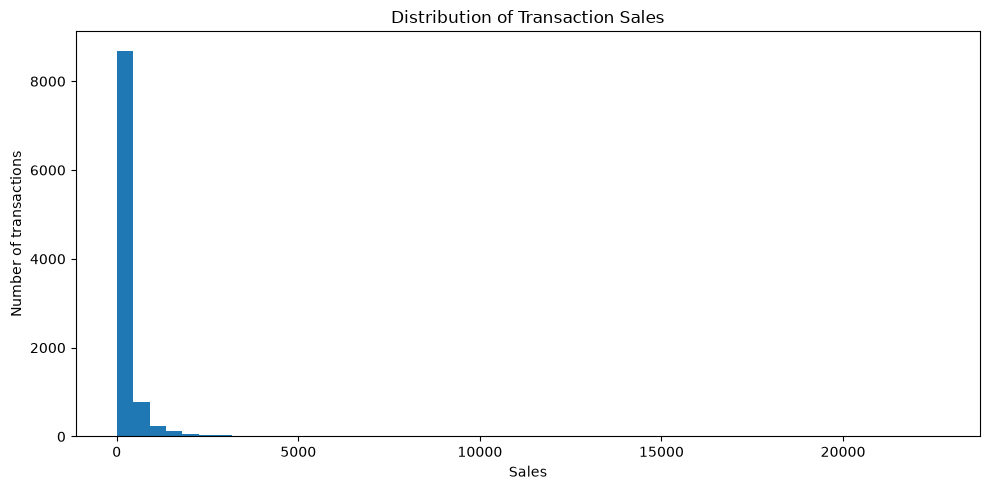

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["sales"],
    bins=50
)

ax.set_title("Distribution of Transaction Sales")
ax.set_xlabel("Sales")
ax.set_ylabel("Number of transactions")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "transaction_sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

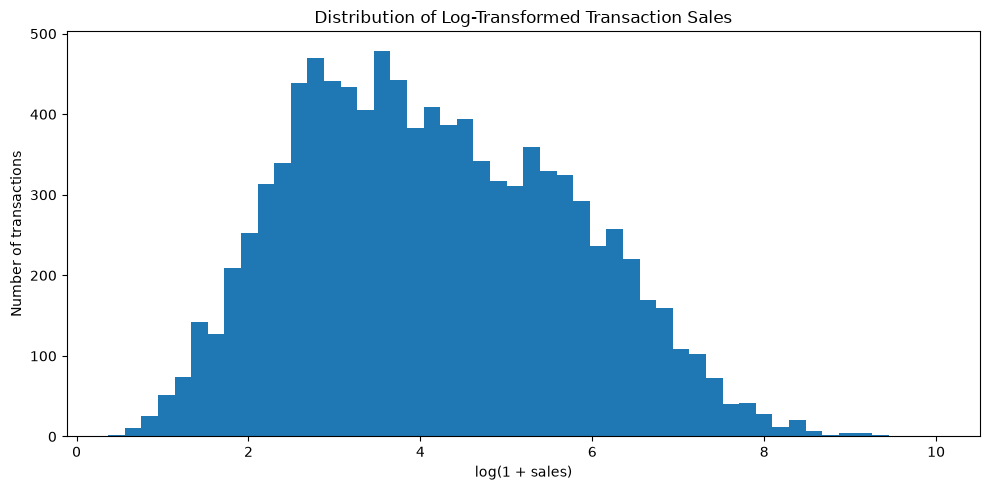

In [45]:
positive_sales = df.loc[df["sales"] > 0, "sales"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    np.log1p(positive_sales),
    bins=50
)

ax.set_title("Distribution of Log-Transformed Transaction Sales")
ax.set_xlabel("log(1 + sales)")
ax.set_ylabel("Number of transactions")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "log_transaction_sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
category_summary = (
    df.groupby("category", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
    )
    .sort_values("sales", ascending=False)
)

category_summary

,category,sales,profit,quantity
2,Technology,"836,154.03","145,454.95",6939
0,Furniture,"741,999.80","18,451.27",8028
1,Office Supplies,"719,047.03","122,490.80",22906


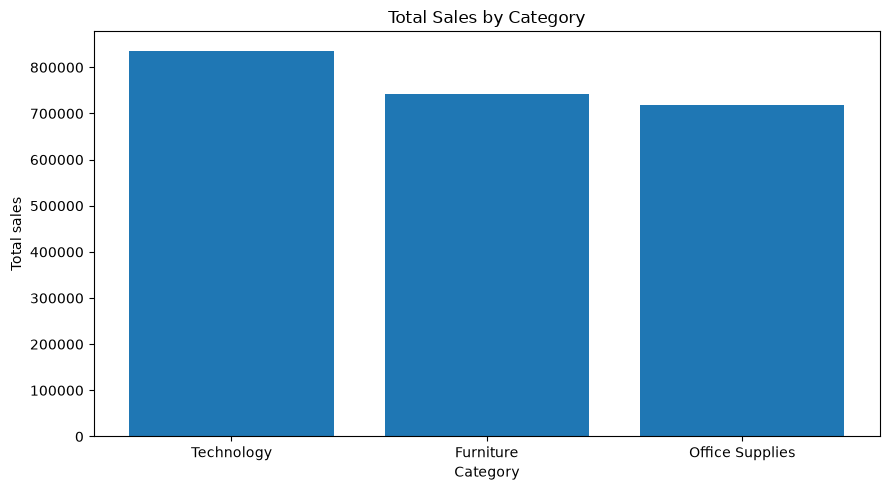

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    category_summary["category"],
    category_summary["sales"]
)

ax.set_title("Total Sales by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total sales")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
region_summary = (
    df.groupby("region", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
    )
    .sort_values("sales", ascending=False)
)

region_summary

,region,sales,profit,orders
3,West,"725,457.82","108,418.45",1611
1,East,"678,781.24","91,522.78",1401
0,Central,"501,239.89","39,706.36",1175
2,South,"391,721.91","46,749.43",822


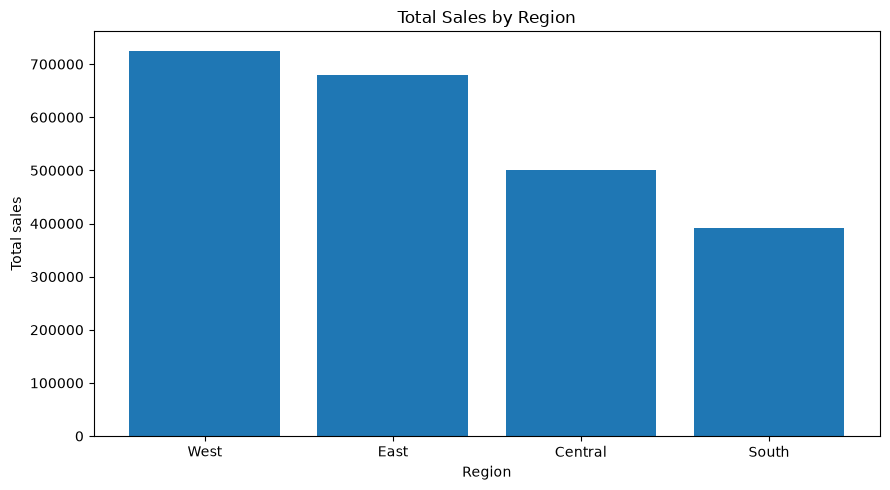

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    region_summary["region"],
    region_summary["sales"]
)

ax.set_title("Total Sales by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Total sales")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
sub_category_summary = (
    df.groupby("sub_category", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
    )
    .sort_values("profit")
)

sub_category_summary

,sub_category,sales,profit
16,Tables,"206,965.53","-17,725.48"
4,Bookcases,"114,880.00","-3,472.56"
15,Supplies,"46,673.54","-1,189.10"
8,Fasteners,"3,024.28",949.52
11,Machines,"189,238.63","3,384.76"
10,Labels,"12,486.31","5,546.25"
2,Art,"27,118.79","6,527.79"
7,Envelopes,"16,476.40","6,964.18"
9,Furnishings,"91,705.16","13,059.14"
1,Appliances,"107,532.16","18,138.01"


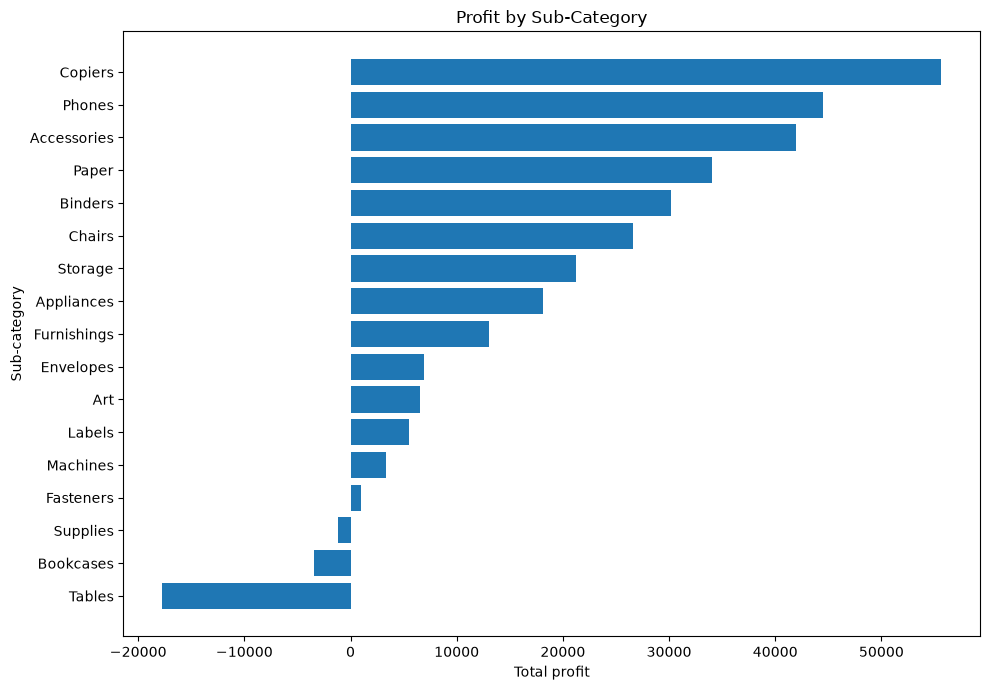

In [51]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    sub_category_summary["sub_category"],
    sub_category_summary["profit"]
)

ax.set_title("Profit by Sub-Category")
ax.set_xlabel("Total profit")
ax.set_ylabel("Sub-category")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "profit_by_sub_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
category_summary.to_csv(
    TABLES_DIR / "category_summary.csv",
    index=False
)

region_summary.to_csv(
    TABLES_DIR / "region_summary.csv",
    index=False
)

sub_category_summary.to_csv(
    TABLES_DIR / "sub_category_summary.csv",
    index=False
)

print("EDA tables saved.")

EDA tables saved.


# 5. Monthly sales aggregation

Transactions are aggregated into total monthly sales.

Monthly aggregation is appropriate because the dataset covers approximately four years and forecasting is intended for business planning rather than individual transactions.

In [53]:
monthly_sales = (
    df.set_index("order_date")
    .resample("MS")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
    )
    .reset_index()
    .rename(columns={"order_date": "date"})
)

monthly_sales.head()

,date,sales,profit,quantity,orders
0,2014-01-01,"14,236.90","2,450.19",284,32
1,2014-02-01,"4,519.89",862.31,159,28
2,2014-03-01,"55,691.01",498.73,585,71
3,2014-04-01,"28,295.35","3,488.84",536,66
4,2014-05-01,"23,648.29","2,738.71",466,69


In [54]:
expected_months = pd.date_range(
    start=monthly_sales["date"].min(),
    end=monthly_sales["date"].max(),
    freq="MS",
)

missing_months = expected_months.difference(
    monthly_sales["date"]
)

print(f"Expected months: {len(expected_months)}")
print(f"Observed months: {len(monthly_sales)}")
print(f"Missing months: {len(missing_months)}")

if len(missing_months) > 0:
    print(missing_months)

Expected months: 48
Observed months: 48
Missing months: 0


In [55]:
monthly_sales = (
    monthly_sales.set_index("date")
    .reindex(expected_months)
    .rename_axis("date")
    .reset_index()
)

monthly_sales[
    ["sales", "profit", "quantity", "orders"]
] = monthly_sales[
    ["sales", "profit", "quantity", "orders"]
].fillna(0)

monthly_sales.head()

,date,sales,profit,quantity,orders
0,2014-01-01,"14,236.90","2,450.19",284,32
1,2014-02-01,"4,519.89",862.31,159,28
2,2014-03-01,"55,691.01",498.73,585,71
3,2014-04-01,"28,295.35","3,488.84",536,66
4,2014-05-01,"23,648.29","2,738.71",466,69


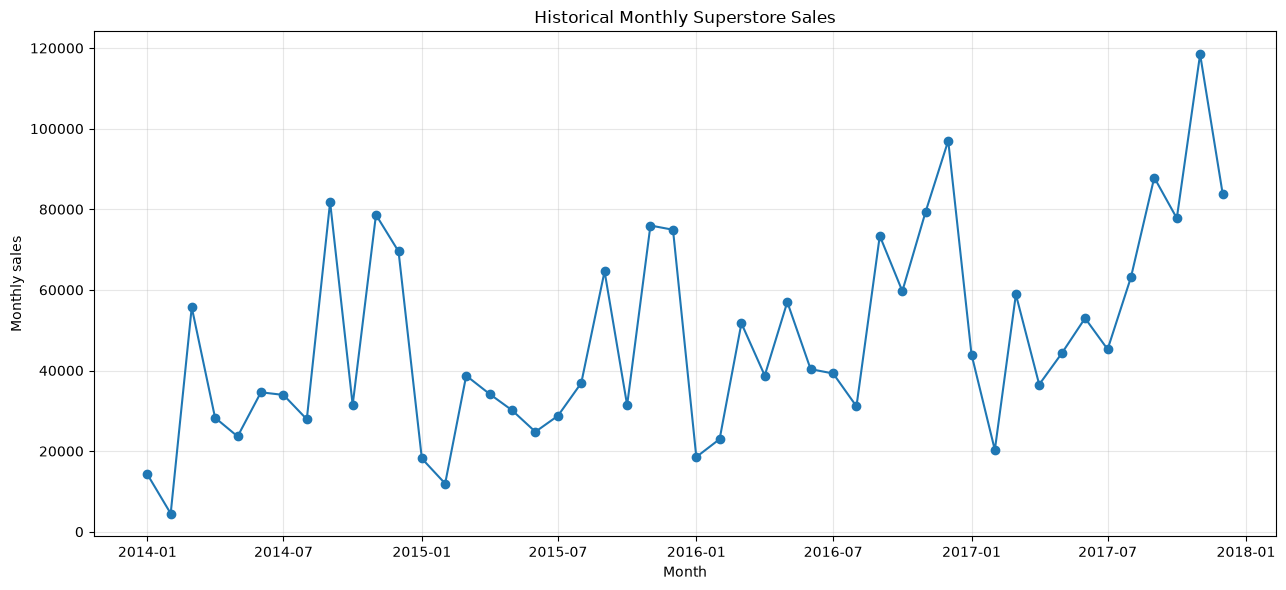

In [56]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    monthly_sales["date"],
    monthly_sales["sales"],
    marker="o"
)

ax.set_title("Historical Monthly Superstore Sales")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly sales")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "historical_monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

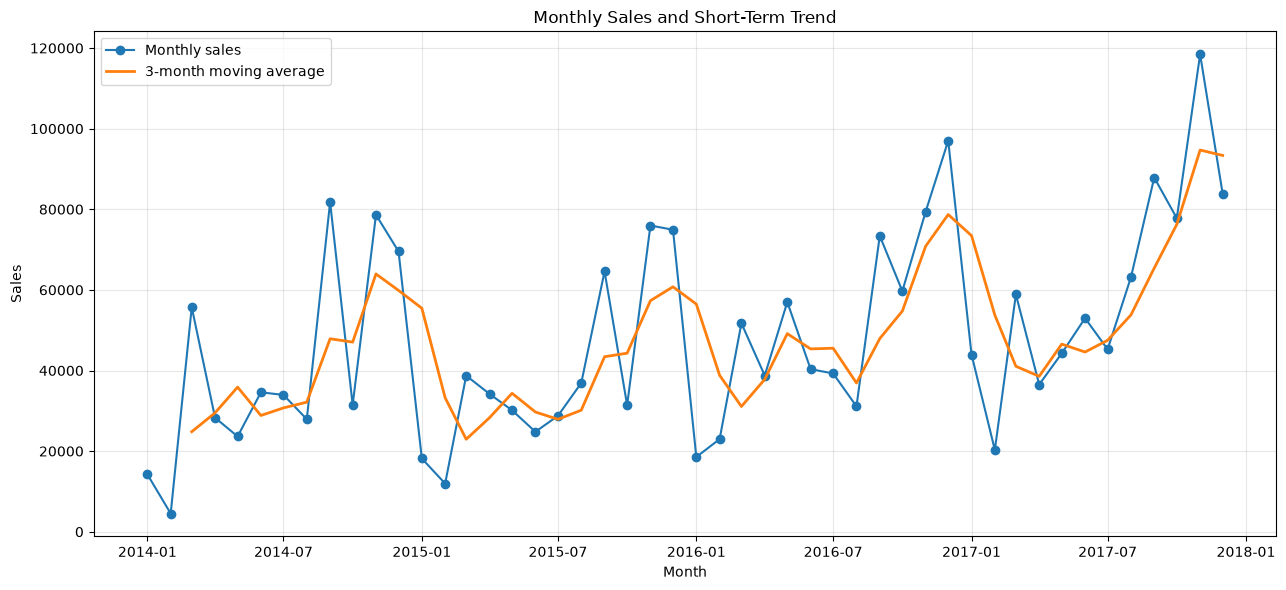

In [57]:
monthly_sales["sales_3_month_moving_average"] = (
    monthly_sales["sales"]
    .rolling(window=3)
    .mean()
)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    monthly_sales["date"],
    monthly_sales["sales"],
    marker="o",
    label="Monthly sales"
)

ax.plot(
    monthly_sales["date"],
    monthly_sales["sales_3_month_moving_average"],
    linewidth=2,
    label="3-month moving average"
)

ax.set_title("Monthly Sales and Short-Term Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
monthly_sales["month_number"] = monthly_sales["date"].dt.month
monthly_sales["month_name"] = monthly_sales["date"].dt.month_name()

month_order = list(range(1, 13))

seasonality_summary = (
    monthly_sales.groupby(
        ["month_number", "month_name"],
        as_index=False
    )
    .agg(
        average_sales=("sales", "mean"),
        median_sales=("sales", "median"),
    )
    .sort_values("month_number")
)

seasonality_summary

,month_number,month_name,average_sales,median_sales
0,1,January,"23,731.21","18,358.28"
1,2,February,"14,937.81","16,126.27"
2,3,March,"51,251.37","53,703.44"
3,4,April,"34,440.53","35,358.37"
4,5,May,"38,757.20","37,196.40"
5,6,June,"38,179.67","37,469.83"
6,7,July,"36,809.52","36,604.18"
7,8,August,"39,761.02","34,006.85"
8,9,September,"76,912.49","77,593.69"
9,10,October,"50,080.75","45,570.57"


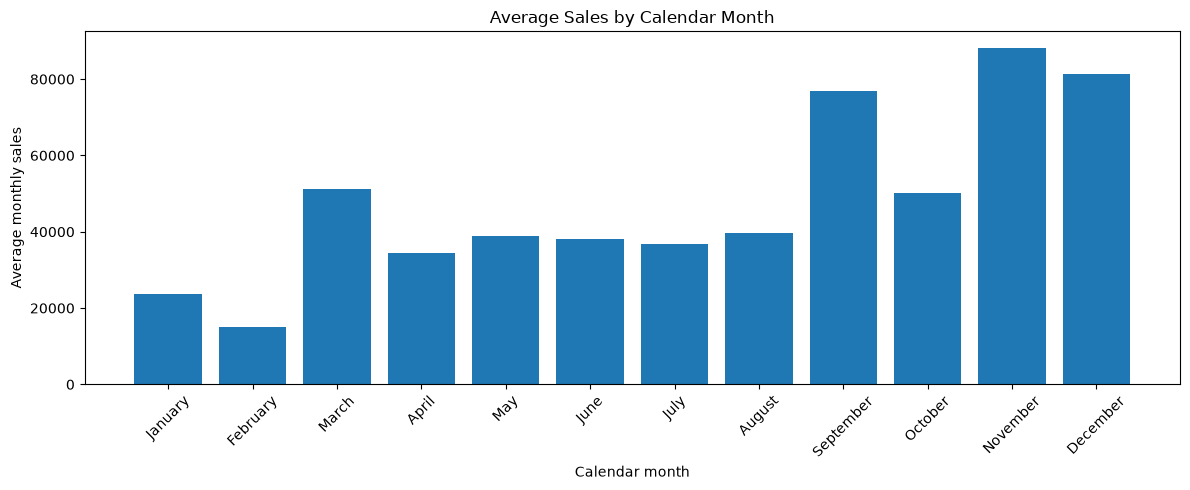

In [59]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    seasonality_summary["month_name"],
    seasonality_summary["average_sales"]
)

ax.set_title("Average Sales by Calendar Month")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Average monthly sales")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "monthly_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
monthly_sales_path = (
    DATA_PROCESSED_DIR / "monthly_superstore_sales.csv"
)

monthly_sales.to_csv(
    monthly_sales_path,
    index=False
)

seasonality_summary.to_csv(
    TABLES_DIR / "seasonality_summary.csv",
    index=False
)

print(f"Monthly sales saved to:\n{monthly_sales_path}")

Monthly sales saved to:
c:\Users\Enat\Documents\superstore-sales-forecasting\data\processed\monthly_superstore_sales.csv


# 6. Time-series feature engineering

The machine-learning models use:

- year
- month
- quarter
- numerical time trend
- cyclical month seasonality
- sales lag values
- rolling averages calculated from previous sales

To prevent target leakage, all lag and rolling features are derived from prior observations only.

In [63]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import joblib

print("Modeling libraries imported.")

Modeling libraries imported.


In [64]:
LAGS = [1, 2, 3, 6, 12]
ROLLING_WINDOWS = [3, 6, 12]


def create_features_for_date(
    forecast_date: pd.Timestamp,
    history: list[float],
    trend_index: int,
) -> dict:
    """
    Create leakage-safe features for one forecast date.

    Parameters
    ----------
    forecast_date:
        Month being predicted.

    history:
        Sales values available before forecast_date. During recursive
        forecasting, previous predictions are added to this history.

    trend_index:
        Numerical time position of forecast_date.

    Returns
    -------
    dict
        Feature names and values.
    """
    month = forecast_date.month
    quarter = forecast_date.quarter

    features = {
        "year": forecast_date.year,
        "month": month,
        "quarter": quarter,
        "trend": trend_index,
        "month_sin": np.sin(2 * np.pi * month / 12),
        "month_cos": np.cos(2 * np.pi * month / 12),
    }

    for lag in LAGS:
        features[f"lag_{lag}"] = (
            history[-lag]
            if len(history) >= lag
            else np.nan
        )

    for window in ROLLING_WINDOWS:
        features[f"rolling_mean_{window}"] = (
            float(np.mean(history[-window:]))
            if len(history) >= window
            else np.nan
        )

        features[f"rolling_std_{window}"] = (
            float(np.std(history[-window:], ddof=1))
            if len(history) >= window
            else np.nan
        )

    return features

In [65]:
def build_supervised_dataset(
    dates: pd.Series,
    sales: pd.Series,
) -> pd.DataFrame:
    """
    Build a supervised time-series dataset using only prior sales values.
    """
    records = []
    history = []

    for trend_index, (date, target_sales) in enumerate(
        zip(dates, sales)
    ):
        feature_record = create_features_for_date(
            forecast_date=pd.Timestamp(date),
            history=history,
            trend_index=trend_index,
        )

        feature_record["date"] = pd.Timestamp(date)
        feature_record["target_sales"] = float(target_sales)

        records.append(feature_record)
        history.append(float(target_sales))

    return pd.DataFrame(records)


supervised_data = build_supervised_dataset(
    dates=monthly_sales["date"],
    sales=monthly_sales["sales"],
)

supervised_data.head(15)

,year,month,quarter,trend,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,date,target_sales
0,2014,1,1,0,0.50,0.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-01,"14,236.90"
1,2014,2,1,1,0.87,0.50,"14,236.90",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-01,"4,519.89"
2,2014,3,1,2,1.00,0.00,"4,519.89","14,236.90",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-01,"55,691.01"
3,2014,4,2,3,0.87,-0.50,"55,691.01","4,519.89","14,236.90",NaN,NaN,"24,815.93","27,176.42",NaN,NaN,NaN,NaN,2014-04-01,"28,295.35"
4,2014,5,2,4,0.50,-0.87,"28,295.35","55,691.01","4,519.89",NaN,NaN,"29,502.08","25,606.89",NaN,NaN,NaN,NaN,2014-05-01,"23,648.29"
5,2014,6,2,5,0.00,-1.00,"23,648.29","28,295.35","55,691.01",NaN,NaN,"35,878.21","17,314.99",NaN,NaN,NaN,NaN,2014-06-01,"34,595.13"
6,2014,7,3,6,-0.50,-0.87,"34,595.13","23,648.29","28,295.35","14,236.90",NaN,"28,846.25","5,494.17","26,831.09","17,674.01",NaN,NaN,2014-07-01,"33,946.39"
7,2014,8,3,7,-0.87,-0.50,"33,946.39","34,595.13","23,648.29","4,519.89",NaN,"30,729.94","6,141.46","30,116.01","16,668.07",NaN,NaN,2014-08-01,"27,909.47"
8,2014,9,3,8,-1.00,-0.00,"27,909.47","33,946.39","34,595.13","55,691.01",NaN,"32,150.33","3,686.99","34,014.27","11,381.14",NaN,NaN,2014-09-01,"81,777.35"
9,2014,10,4,9,-0.87,0.50,"81,777.35","27,909.47","33,946.39","28,295.35",NaN,"47,877.74","29,512.69","38,362.00","21,659.48",NaN,NaN,2014-10-01,"31,453.39"


In [66]:
feature_columns = [
    "year",
    "month",
    "quarter",
    "trend",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_std_3",
    "rolling_mean_6",
    "rolling_std_6",
    "rolling_mean_12",
    "rolling_std_12",
]

modeling_data = (
    supervised_data
    .dropna(subset=feature_columns)
    .reset_index(drop=True)
)

print(f"Original monthly observations: {len(monthly_sales)}")
print(f"Usable supervised observations: {len(modeling_data)}")

modeling_data.head()

Original monthly observations: 48
Usable supervised observations: 36


,year,month,quarter,trend,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,date,target_sales
0,2015,1,1,12,0.50,0.87,"69,545.62","78,628.72","31,453.39","33,946.39","14,236.90","59,875.91","25,030.09","53,876.82","25,341.44","40,353.96","25,167.10",2015-01-01,"18,174.08"
1,2015,2,1,13,0.87,0.50,"18,174.08","69,545.62","78,628.72","27,909.47","4,519.89","55,449.47","32,599.34","51,248.10","28,449.77","40,682.06","24,818.92",2015-02-01,"11,951.41"
2,2015,3,1,14,1.00,0.00,"11,951.41","18,174.08","69,545.62","81,777.35","55,691.01","33,223.70","31,609.20","48,588.43","31,635.55","41,301.35","23,910.65",2015-03-01,"38,726.25"
3,2015,4,2,15,0.87,-0.50,"38,726.25","11,951.41","18,174.08","31,453.39","28,295.35","22,950.58","14,011.93","41,413.24","27,169.46","39,887.62","23,480.16",2015-04-01,"34,195.21"
4,2015,5,2,16,0.50,-0.87,"34,195.21","38,726.25","11,951.41","78,628.72","23,648.29","28,290.96","14,330.67","41,870.21","26,990.92","40,379.28","23,276.24",2015-05-01,"30,131.69"


In [67]:
modeling_data.to_csv(
    DATA_PROCESSED_DIR / "monthly_modeling_features.csv",
    index=False
)

print("Engineered feature dataset saved.")

Engineered feature dataset saved.


# 7. Chronological train-test split

The final 12 months are reserved for testing.

A random split is not appropriate because it would allow future observations to appear in the training data and would produce an unrealistic evaluation.

The models must predict the entire test horizon without using actual test-period sales as lag inputs.

In [68]:
TEST_MONTHS = 12

if len(monthly_sales) <= TEST_MONTHS + max(LAGS):
    raise ValueError(
        "There are not enough monthly observations for the selected "
        "lag structure and test period."
    )

test_start_position = len(monthly_sales) - TEST_MONTHS
test_start_date = monthly_sales.loc[
    test_start_position,
    "date"
]

train_series = monthly_sales.iloc[
    :test_start_position
].copy()

test_series = monthly_sales.iloc[
    test_start_position:
].copy()

print(
    f"Training period: "
    f"{train_series['date'].min():%Y-%m} to "
    f"{train_series['date'].max():%Y-%m}"
)

print(
    f"Test period: "
    f"{test_series['date'].min():%Y-%m} to "
    f"{test_series['date'].max():%Y-%m}"
)

print(f"Training months: {len(train_series)}")
print(f"Test months: {len(test_series)}")

Training period: 2014-01 to 2016-12
Test period: 2017-01 to 2017-12
Training months: 36
Test months: 12


In [69]:
ml_train_data = modeling_data[
    modeling_data["date"] < test_start_date
].copy()

X_train = ml_train_data[feature_columns]
y_train = ml_train_data["target_sales"]

print(f"ML training rows: {len(X_train)}")
print(f"Number of features: {X_train.shape[1]}")

ML training rows: 24
Number of features: 17


In [70]:
assert ml_train_data["date"].max() < test_series["date"].min()
assert len(test_series) == TEST_MONTHS
assert train_series["date"].max() < test_series["date"].min()

print("Chronological split verification passed.")

Chronological split verification passed.


# 8. Train Linear Regression and Random Forest

In [73]:
# Create the models.

linear_regression_model = LinearRegression()

random_forest_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

In [74]:
# Train Both Models
linear_regression_model.fit(
    X_train,
    y_train
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained.")
print("Random Forest trained.")

Linear Regression trained.
Random Forest trained.


In [75]:
# Recursive Forecasting Function

def recursive_ml_forecast(
    model,
    historical_dates: pd.Series,
    historical_sales: pd.Series,
    forecast_dates: pd.Series | pd.DatetimeIndex,
    feature_names: list[str],
) -> np.ndarray:
    """
    Forecast multiple future months recursively without target leakage.
    """
    history = historical_sales.astype(float).tolist()
    predictions = []

    starting_trend_index = len(historical_dates)

    for step, forecast_date in enumerate(forecast_dates):
        feature_record = create_features_for_date(
            forecast_date=pd.Timestamp(forecast_date),
            history=history,
            trend_index=starting_trend_index + step,
        )

        feature_frame = pd.DataFrame(
            [feature_record]
        )[feature_names]

        prediction = float(
            model.predict(feature_frame)[0]
        )

        # Sales cannot be negative.
        prediction = max(0.0, prediction)

        predictions.append(prediction)
        history.append(prediction)

    return np.array(predictions)

In [76]:
# Generate test predictions for both models.

linear_test_predictions = recursive_ml_forecast(
    model=linear_regression_model,
    historical_dates=train_series["date"],
    historical_sales=train_series["sales"],
    forecast_dates=test_series["date"],
    feature_names=feature_columns,
)

random_forest_test_predictions = recursive_ml_forecast(
    model=random_forest_model,
    historical_dates=train_series["date"],
    historical_sales=train_series["sales"],
    forecast_dates=test_series["date"],
    feature_names=feature_columns,
)

print("Recursive machine-learning test forecasts created.")

Recursive machine-learning test forecasts created.


# 9. Train Exponential Smoothing

In [77]:
exponential_smoothing_model = ExponentialSmoothing(
    train_series["sales"].astype(float),
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    damped_trend=True,
    initialization_method="estimated",
)

exponential_smoothing_fit = (
    exponential_smoothing_model.fit(
        optimized=True
    )
)

ets_test_predictions = np.maximum(
    exponential_smoothing_fit.forecast(TEST_MONTHS),
    0
)

print("Exponential Smoothing model trained.")

Exponential Smoothing model trained.


# 10. Model Evaluation

In [79]:
# Create evaluation functions.

def calculate_mape(
    actual: np.ndarray | pd.Series,
    predicted: np.ndarray | pd.Series,
) -> float:
    """
    Calculate zero-safe Mean Absolute Percentage Error.
    """
    actual_array = np.asarray(actual, dtype=float)
    predicted_array = np.asarray(predicted, dtype=float)

    nonzero_mask = actual_array != 0

    if not nonzero_mask.any():
        return np.nan

    percentage_errors = np.abs(
        (
            actual_array[nonzero_mask]
            - predicted_array[nonzero_mask]
        )
        / actual_array[nonzero_mask]
    )

    return float(np.mean(percentage_errors) * 100)


def evaluate_forecast(
    model_name: str,
    actual: np.ndarray | pd.Series,
    predicted: np.ndarray | pd.Series,
) -> dict:
    """
    Calculate MAE, RMSE, and MAPE.
    """
    actual_array = np.asarray(actual, dtype=float)
    predicted_array = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(
        actual_array,
        predicted_array
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_array,
            predicted_array
        )
    )

    mape = calculate_mape(
        actual_array,
        predicted_array
    )

    return {
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "mape_percent": mape,
    }


In [80]:
# Compare models

actual_test_sales = test_series["sales"].to_numpy()

model_results = [
    evaluate_forecast(
        "Linear Regression",
        actual_test_sales,
        linear_test_predictions,
    ),
    evaluate_forecast(
        "Random Forest",
        actual_test_sales,
        random_forest_test_predictions,
    ),
    evaluate_forecast(
        "Exponential Smoothing",
        actual_test_sales,
        ets_test_predictions,
    ),
]

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

model_comparison

,model,mae,rmse,mape_percent
0,Exponential Smoothing,"10,896.75","14,120.44",18.50
1,Random Forest,"14,474.69","17,688.51",24.30
2,Linear Regression,"18,499.20","22,319.90",35.41


In [81]:
model_comparison.to_csv(
    TABLES_DIR / "model_comparison.csv",
    index=False
)

best_model_name = model_comparison.loc[0, "model"]

print(f"Best model by RMSE: {best_model_name}")

Best model by RMSE: Exponential Smoothing


In [82]:
test_predictions = pd.DataFrame(
    {
        "date": test_series["date"].to_numpy(),
        "actual_sales": actual_test_sales,
        "linear_regression_prediction": linear_test_predictions,
        "random_forest_prediction": random_forest_test_predictions,
        "exponential_smoothing_prediction": np.asarray(
            ets_test_predictions
        ),
    }
)

test_predictions

,date,actual_sales,linear_regression_prediction,random_forest_prediction,exponential_smoothing_prediction
0,2017-01-01,"43,971.37","60,969.78","30,935.90","29,650.73"
1,2017-02-01,"20,301.13","39,267.16","30,673.72","26,174.63"
2,2017-03-01,"58,872.35","38,763.73","43,860.08","61,309.47"
3,2017-04-01,"36,521.54","64,939.83","40,145.53","46,712.67"
4,2017-05-01,"44,261.11","63,951.04","48,416.37","49,957.39"
5,2017-06-01,"52,981.73","52,611.46","41,708.39","45,587.97"
6,2017-07-01,"45,264.42","43,425.60","36,829.77","46,283.08"
7,2017-08-01,"63,120.89","37,215.51","35,831.15","44,173.48"
8,2017-09-01,"87,866.65","65,632.77","70,811.54","85,102.23"
9,2017-10-01,"77,776.92","62,030.34","58,667.76","51,736.81"


In [83]:
test_predictions.to_csv(
    TABLES_DIR / "test_predictions.csv",
    index=False
)

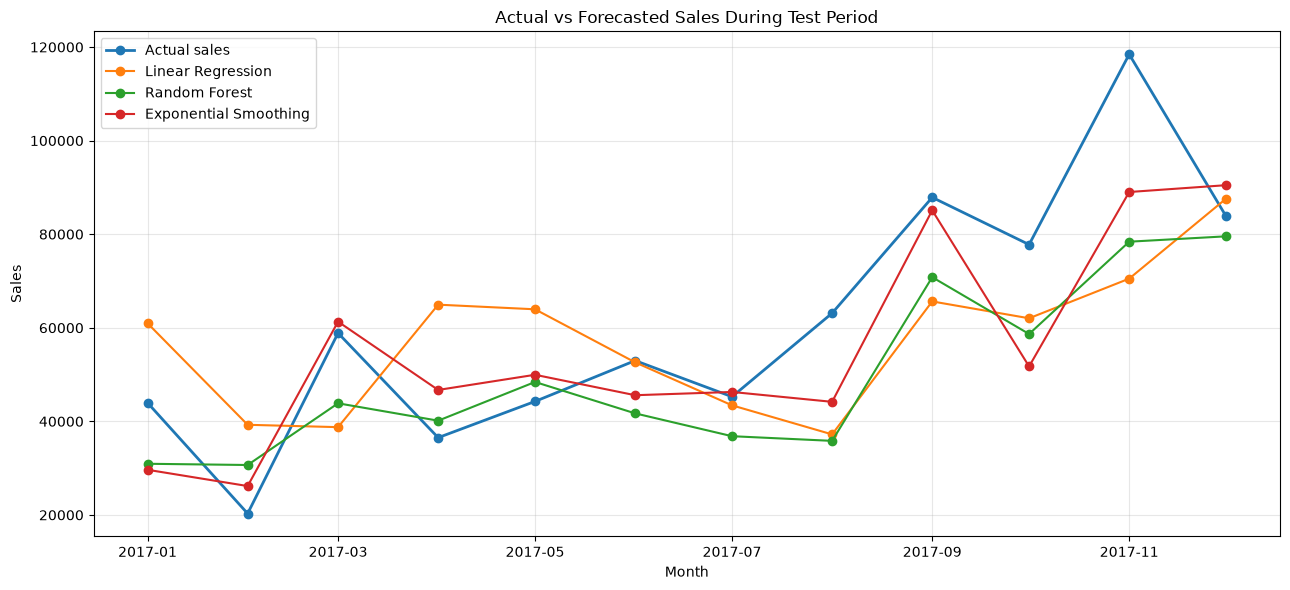

In [84]:
# Plot all test predictions.

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    test_predictions["date"],
    test_predictions["actual_sales"],
    marker="o",
    linewidth=2,
    label="Actual sales",
)

ax.plot(
    test_predictions["date"],
    test_predictions["linear_regression_prediction"],
    marker="o",
    label="Linear Regression",
)

ax.plot(
    test_predictions["date"],
    test_predictions["random_forest_prediction"],
    marker="o",
    label="Random Forest",
)

ax.plot(
    test_predictions["date"],
    test_predictions["exponential_smoothing_prediction"],
    marker="o",
    label="Exponential Smoothing",
)

ax.set_title("Actual vs Forecasted Sales During Test Period")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "test_model_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. Error Analysis

In [ ]:
# Select the best test predictions.

prediction_column_by_model = {
    "Linear Regression": "linear_regression_prediction",
    "Random Forest": "random_forest_prediction",
    "Exponential Smoothing": "exponential_smoothing_prediction",
}

best_prediction_column = prediction_column_by_model[
    best_model_name
]

error_analysis = test_predictions[
    ["date", "actual_sales", best_prediction_column]
].copy()

error_analysis = error_analysis.rename(
    columns={
        best_prediction_column: "predicted_sales"
    }
)

error_analysis["error"] = (
    error_analysis["actual_sales"]
    - error_analysis["predicted_sales"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"].abs()
)

error_analysis["percentage_error"] = np.where(
    error_analysis["actual_sales"] != 0,
    error_analysis["absolute_error"]
    / error_analysis["actual_sales"]
    * 100,
    np.nan,
)

error_analysis

,date,actual_sales,predicted_sales,error,absolute_error,percentage_error
0,2017-01-01,"43,971.37","29,650.73","14,320.64","14,320.64",32.57
1,2017-02-01,"20,301.13","26,174.63","-5,873.50","5,873.50",28.93
2,2017-03-01,"58,872.35","61,309.47","-2,437.12","2,437.12",4.14
3,2017-04-01,"36,521.54","46,712.67","-10,191.14","10,191.14",27.90
4,2017-05-01,"44,261.11","49,957.39","-5,696.28","5,696.28",12.87
5,2017-06-01,"52,981.73","45,587.97","7,393.76","7,393.76",13.96
6,2017-07-01,"45,264.42","46,283.08","-1,018.67","1,018.67",2.25
7,2017-08-01,"63,120.89","44,173.48","18,947.41","18,947.41",30.02
8,2017-09-01,"87,866.65","85,102.23","2,764.42","2,764.42",3.15
9,2017-10-01,"77,776.92","51,736.81","26,040.12","26,040.12",33.48


In [ ]:
# find largest errors.

largest_errors = (
    error_analysis
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(5)
)

largest_errors

,date,actual_sales,predicted_sales,error,absolute_error,percentage_error
10,2017-11-01,"118,447.82","89,016.55","29,431.27","29,431.27",24.85
9,2017-10-01,"77,776.92","51,736.81","26,040.12","26,040.12",33.48
7,2017-08-01,"63,120.89","44,173.48","18,947.41","18,947.41",30.02
0,2017-01-01,"43,971.37","29,650.73","14,320.64","14,320.64",32.57
3,2017-04-01,"36,521.54","46,712.67","-10,191.14","10,191.14",27.90


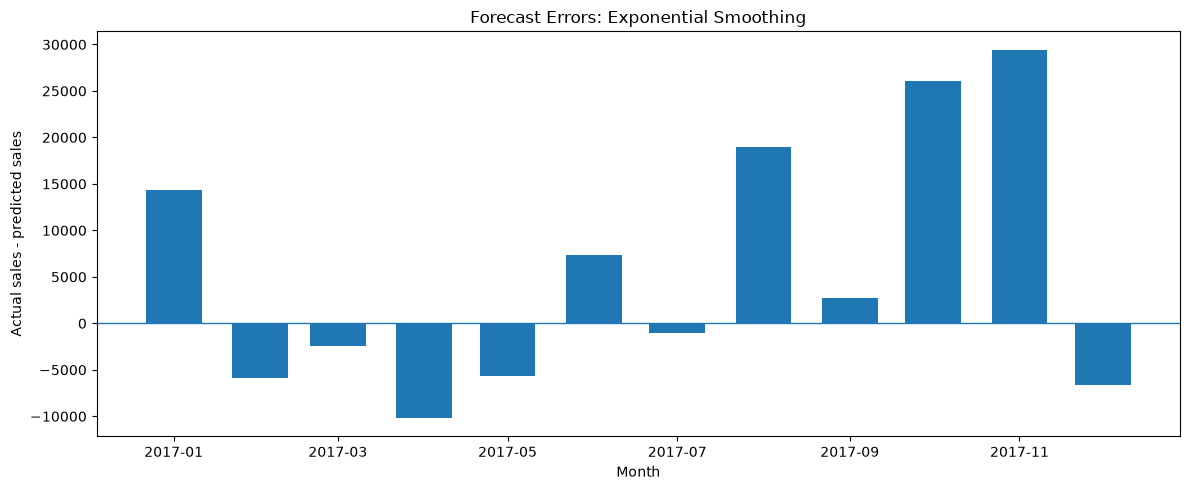

In [87]:
# Plot forecast errors.

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    error_analysis["date"],
    error_analysis["error"],
    width=20,
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(f"Forecast Errors: {best_model_name}")
ax.set_xlabel("Month")
ax.set_ylabel("Actual sales - predicted sales")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "best_model_forecast_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

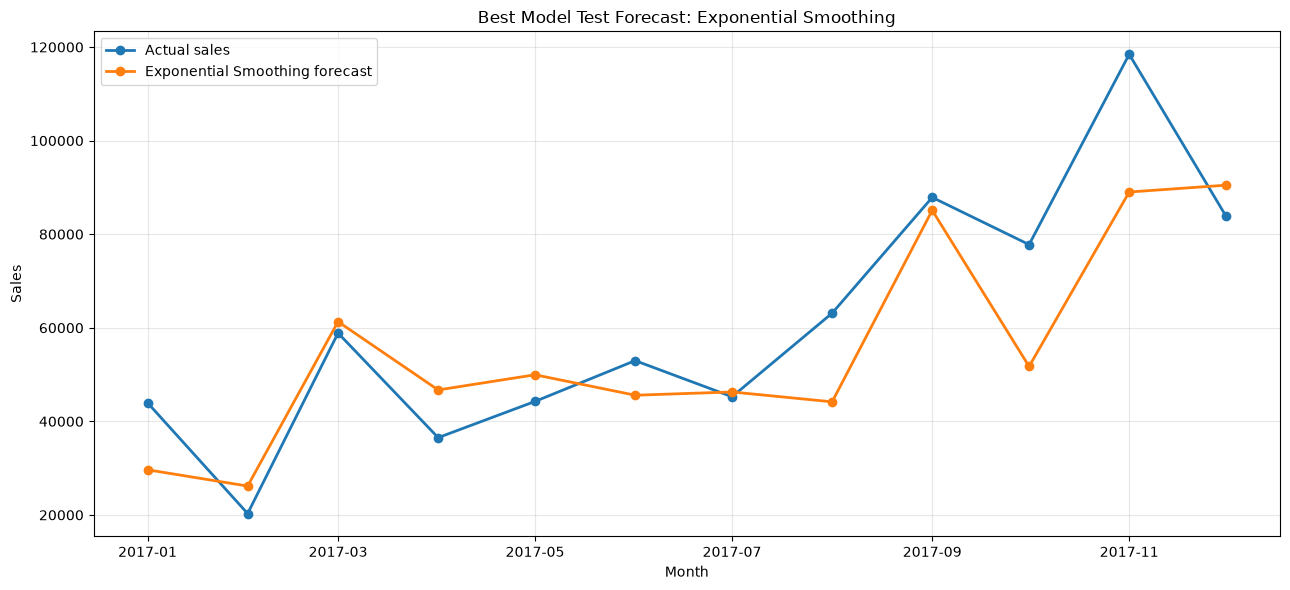

In [88]:
# Plot actual vs selected model.

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    error_analysis["date"],
    error_analysis["actual_sales"],
    marker="o",
    linewidth=2,
    label="Actual sales",
)

ax.plot(
    error_analysis["date"],
    error_analysis["predicted_sales"],
    marker="o",
    linewidth=2,
    label=f"{best_model_name} forecast",
)

ax.set_title(
    f"Best Model Test Forecast: {best_model_name}"
)

ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "best_model_test_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
# Save eror analysis

error_analysis.to_csv(
    TABLES_DIR / "best_model_error_analysis.csv",
    index=False
)

largest_errors.to_csv(
    TABLES_DIR / "largest_forecast_errors.csv",
    index=False
)

# 12. Random Forest feature importance

In [90]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "importance": (
                random_forest_model.feature_importances_
            ),
        }
    )
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance

,feature,importance
10,lag_12,0.49
1,month,0.23
16,rolling_std_12,0.06
3,trend,0.04
13,rolling_mean_6,0.03
2,quarter,0.03
7,lag_2,0.03
9,lag_6,0.02
15,rolling_mean_12,0.02
11,rolling_mean_3,0.02


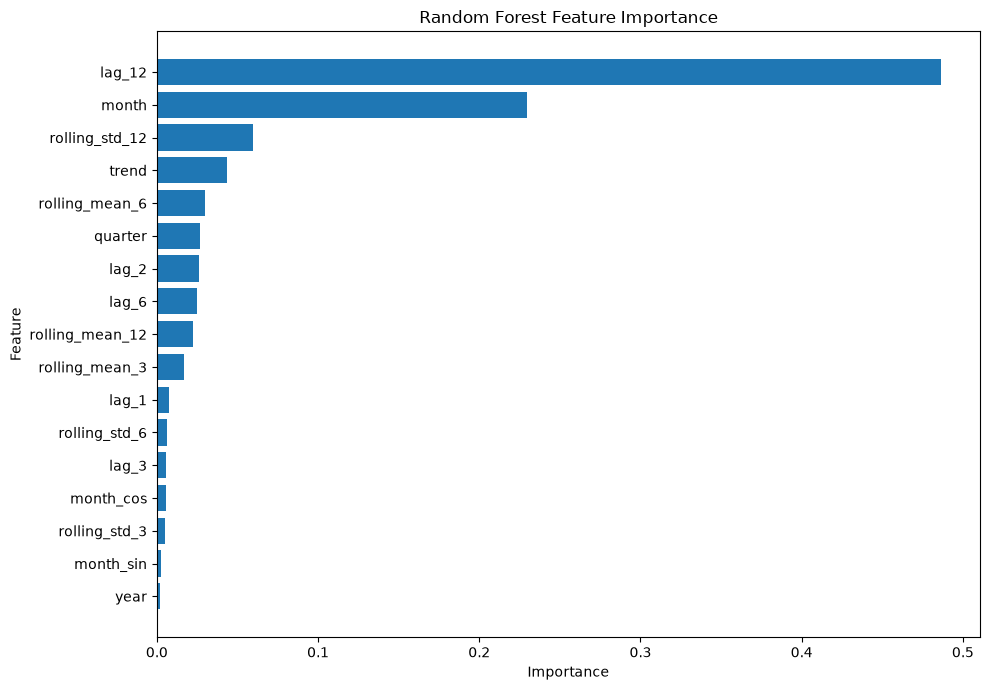

In [91]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_data = feature_importance.sort_values(
    "importance"
)

ax.barh(
    plot_data["feature"],
    plot_data["importance"]
)

ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
feature_importance.to_csv(
    TABLES_DIR / "random_forest_feature_importance.csv",
    index=False
)

# 13. Refit the selected model and forecast the future

In [93]:
# Define future dates

FORECAST_MONTHS = 12

future_dates = pd.date_range(
    start=monthly_sales["date"].max()
    + pd.offsets.MonthBegin(1),
    periods=FORECAST_MONTHS,
    freq="MS",
)

future_dates

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01'],
              dtype='datetime64[us]', freq='MS')

In [94]:
# Build full ML training data
full_ml_training_data = modeling_data.copy()

X_full = full_ml_training_data[feature_columns]
y_full = full_ml_training_data["target_sales"]

In [95]:
# Refit and forecast according to selected model

selected_model_object = None

if best_model_name == "Linear Regression":
    selected_model_object = LinearRegression()

    selected_model_object.fit(
        X_full,
        y_full
    )

    future_predictions = recursive_ml_forecast(
        model=selected_model_object,
        historical_dates=monthly_sales["date"],
        historical_sales=monthly_sales["sales"],
        forecast_dates=future_dates,
        feature_names=feature_columns,
    )

elif best_model_name == "Random Forest":
    selected_model_object = RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    selected_model_object.fit(
        X_full,
        y_full
    )

    future_predictions = recursive_ml_forecast(
        model=selected_model_object,
        historical_dates=monthly_sales["date"],
        historical_sales=monthly_sales["sales"],
        forecast_dates=future_dates,
        feature_names=feature_columns,
    )

elif best_model_name == "Exponential Smoothing":
    selected_model_object = ExponentialSmoothing(
        monthly_sales["sales"].astype(float),
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        damped_trend=True,
        initialization_method="estimated",
    ).fit(
        optimized=True
    )

    future_predictions = np.maximum(
        selected_model_object.forecast(
            FORECAST_MONTHS
        ),
        0,
    )

else:
    raise ValueError(
        f"Unsupported selected model: {best_model_name}"
    )

print(f"Refitted model: {best_model_name}")

Refitted model: Exponential Smoothing


In [96]:
# Create future forecast table

future_forecast = pd.DataFrame(
    {
        "date": future_dates,
        "forecast_sales": np.asarray(
            future_predictions,
            dtype=float
        ),
    }
)

future_forecast["year"] = (
    future_forecast["date"].dt.year
)

future_forecast["month"] = (
    future_forecast["date"].dt.month_name()
)

future_forecast

,date,forecast_sales,year,month
0,2018-01-01,"49,388.08",2018,January
1,2018-02-01,"41,475.68",2018,February
2,2018-03-01,"75,005.75",2018,March
3,2018-04-01,"61,273.37",2018,April
4,2018-05-01,"67,935.33",2018,May
5,2018-06-01,"65,186.35",2018,June
6,2018-07-01,"66,500.69",2018,July
7,2018-08-01,"66,545.64",2018,August
8,2018-09-01,"107,461.96",2018,September
9,2018-10-01,"77,583.42",2018,October


In [97]:
# Save future predictions

future_forecast.to_csv(
    TABLES_DIR / "future_forecast.csv",
    index=False
)

print("Future forecast saved.")

Future forecast saved.


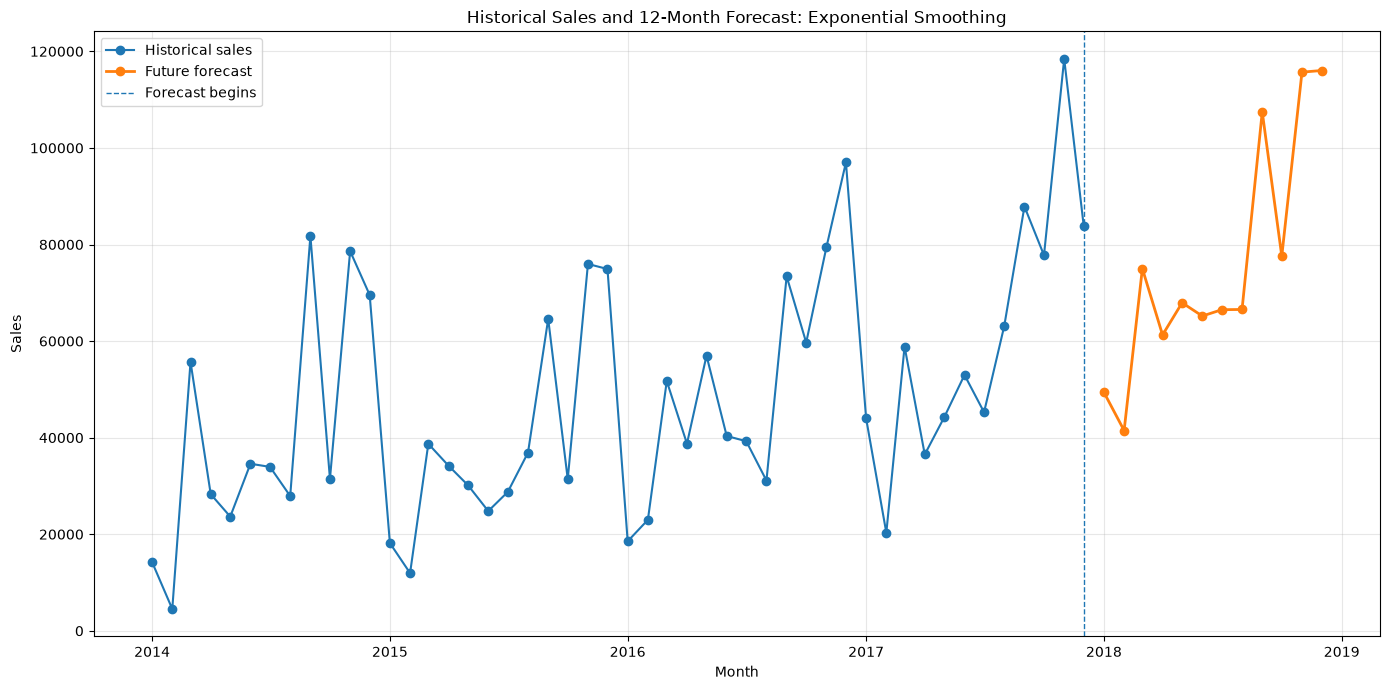

In [98]:
# Plot historical and future sales

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    monthly_sales["date"],
    monthly_sales["sales"],
    marker="o",
    label="Historical sales",
)

ax.plot(
    future_forecast["date"],
    future_forecast["forecast_sales"],
    marker="o",
    linewidth=2,
    label="Future forecast",
)

ax.axvline(
    monthly_sales["date"].max(),
    linestyle="--",
    linewidth=1,
    label="Forecast begins",
)

ax.set_title(
    f"Historical Sales and 12-Month Forecast: "
    f"{best_model_name}"
)

ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "historical_and_future_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [99]:
# Future forecast Summary

forecast_summary = pd.DataFrame(
    {
        "metric": [
            "Selected model",
            "Forecast start",
            "Forecast end",
            "Forecast months",
            "Total forecast sales",
            "Average monthly forecast",
            "Minimum monthly forecast",
            "Maximum monthly forecast",
            "Peak forecast month",
        ],
        "value": [
            best_model_name,
            future_forecast["date"].min().strftime(
                "%Y-%m"
            ),
            future_forecast["date"].max().strftime(
                "%Y-%m"
            ),
            len(future_forecast),
            future_forecast["forecast_sales"].sum(),
            future_forecast["forecast_sales"].mean(),
            future_forecast["forecast_sales"].min(),
            future_forecast["forecast_sales"].max(),
            future_forecast.loc[
                future_forecast[
                    "forecast_sales"
                ].idxmax(),
                "date",
            ].strftime("%Y-%m"),
        ],
    }
)

forecast_summary

,metric,value
0,Selected model,Exponential Smoothing
1,Forecast start,2018-01
2,Forecast end,2018-12
3,Forecast months,12
4,Total forecast sales,"910,080.63"
5,Average monthly forecast,"75,840.05"
6,Minimum monthly forecast,"41,475.68"
7,Maximum monthly forecast,"116,029.87"
8,Peak forecast month,2018-12


In [100]:
forecast_summary.to_csv(
    TABLES_DIR / "forecast_summary.csv",
    index=False
)

# 14. Save the trained model

In [101]:
model_package = {
    "model_name": best_model_name,
    "model": selected_model_object,
    "feature_columns": feature_columns,
    "lags": LAGS,
    "rolling_windows": ROLLING_WINDOWS,
    "training_start": (
        monthly_sales["date"].min()
    ),
    "training_end": (
        monthly_sales["date"].max()
    ),
    "forecast_horizon_months": FORECAST_MONTHS,
}

model_path = MODELS_DIR / "best_sales_forecasting_model.joblib"

joblib.dump(
    model_package,
    model_path
)

print(f"Model saved to:\n{model_path}")

Model saved to:
c:\Users\Enat\Documents\superstore-sales-forecasting\models\best_sales_forecasting_model.joblib


In [102]:
# Verify saved model

loaded_model_package = joblib.load(model_path)

assert loaded_model_package["model_name"] == best_model_name
assert loaded_model_package["model"] is not None

print("Saved model loaded successfully.")
print(
    f"Loaded model: "
    f"{loaded_model_package['model_name']}"
)

Saved model loaded successfully.
Loaded model: Exponential Smoothing


# 15. Business Insights

In [104]:
best_metrics = model_comparison.iloc[0]

peak_month_row = future_forecast.loc[
    future_forecast["forecast_sales"].idxmax()
]

lowest_month_row = future_forecast.loc[
    future_forecast["forecast_sales"].idxmin()
]

print("BUSINESS INTERPRETATION VALUES")
print("-" * 40)
print(f"Best model: {best_model_name}")

print(
    f"Forecast total: "
    f"{future_forecast['forecast_sales'].sum():,.2f}"
)
print(
    f"Average monthly forecast: "
    f"{future_forecast['forecast_sales'].mean():,.2f}"
)
print(
    f"Peak forecast month: "
    f"{peak_month_row['date']:%B %Y}"
)
print(
    f"Peak forecast sales: "
    f"{peak_month_row['forecast_sales']:,.2f}"
)
print(
    f"Lowest forecast month: "
    f"{lowest_month_row['date']:%B %Y}"
)
print(
    f"Lowest forecast sales: "
    f"{lowest_month_row['forecast_sales']:,.2f}"
)

BUSINESS INTERPRETATION VALUES
----------------------------------------
Best model: Exponential Smoothing
Forecast total: 910,080.63
Average monthly forecast: 75,840.05
Peak forecast month: December 2018
Peak forecast sales: 116,029.87
Lowest forecast month: February 2018
Lowest forecast sales: 41,475.68


# Business interpretation

## Future forecast

The model forecasts total sales of approximately **[FORECAST TOTAL]** during the next 12 months.

The average forecast is approximately **[AVERAGE MONTHLY FORECAST]** per month.

The highest projected month is **[PEAK MONTH]**, while the lowest projected month is **[LOWEST MONTH]**.

## Management applications

### Inventory planning

Managers can increase stock availability before projected high-demand months. Slow-moving products should not be increased automatically; category-level forecasts would be needed for product-specific purchasing decisions.

### Staffing

More staff hours can be scheduled during expected peak months. Lower-demand periods can be used for employee training, maintenance, and process improvement.

### Budgeting and cash flow

The monthly forecast can support revenue targets, purchasing budgets, operating expense plans, and cash-flow preparation.

### Promotions

Promotions may be scheduled during weaker forecast months to stimulate demand. Promotions during strong months should focus on margin protection rather than unnecessary discounting.

### Forecast monitoring

Actual sales should be compared with forecasts every month. Large errors may indicate changing customer demand, unusual promotions, supply problems, or market events.

## Limitations

- The dataset contains only about four years of monthly history.
- The forecast uses total sales and does not separately forecast categories, regions, or products.
- Recursive machine-learning forecasts can accumulate error over longer horizons.
- Historical Superstore data is an educational dataset and does not represent current market conditions.

In [107]:
# Save the cleaned transaction data again

cleaned_transactions_path = (
    DATA_PROCESSED_DIR
    / "cleaned_superstore_transactions.csv"
)

df.to_csv(
    cleaned_transactions_path,
    index=False
)

print("Saved successfully:")
print(cleaned_transactions_path)

Saved successfully:
c:\Users\Enat\Documents\superstore-sales-forecasting\data\processed\cleaned_superstore_transactions.csv


In [108]:
required_output_files = [
    DATA_PROCESSED_DIR
    / "cleaned_superstore_transactions.csv",

    DATA_PROCESSED_DIR
    / "monthly_superstore_sales.csv",

    DATA_PROCESSED_DIR
    / "monthly_modeling_features.csv",

    TABLES_DIR
    / "model_comparison.csv",

    TABLES_DIR
    / "test_predictions.csv",

    TABLES_DIR
    / "best_model_error_analysis.csv",

    TABLES_DIR
    / "future_forecast.csv",

    FIGURES_DIR
    / "historical_monthly_sales.png",

    FIGURES_DIR
    / "test_model_predictions.png",

    FIGURES_DIR
    / "historical_and_future_forecast.png",

    MODELS_DIR
    / "best_sales_forecasting_model.joblib",
]

missing_output_files = [
    path
    for path in required_output_files
    if not path.exists()
]

assert not missing_output_files, (
    "Missing expected output files:\n"
    + "\n".join(
        str(path)
        for path in missing_output_files
    )
)

assert len(future_forecast) == FORECAST_MONTHS
assert future_forecast["forecast_sales"].notna().all()
assert (future_forecast["forecast_sales"] >= 0).all()
assert len(model_comparison) == 3

print("Final notebook verification passed.")
print(f"Selected model: {best_model_name}")
print(f"Future forecast months: {len(future_forecast)}")
print("All required output files were created.")


Final notebook verification passed.
Selected model: Exponential Smoothing
Future forecast months: 12
All required output files were created.
